# Data Exploration Noteboook - Google Natural Questions

**Dataset Description** - A large dataset of real anonymised queries issued to the Google search engine, along with corresponding Wikipedia articles that provide answers.

Link to Google's page on [dataset](https://ai.google.com/research/NaturalQuestions)

Notes on data - data is split into train and dev. Train is a set of documents with the user query, the Wiki document where the answer is, a short and long answer. There is also a dev dataset of 200 queries which can be used for the model evaluations

In [1]:
import json

In [2]:
from pydata_manchester_talk.utility import get_long_answer

### Training Dataset

In [3]:
NATURAL_QUESTIONS_TRAINING_DATA_FILE_PATH = "../data/v1.0-simplified_simplified-nq-train.jsonl"

In [4]:
num_lines_to_read = 1000

# Read the first 'num_lines_to_read' lines
subset_training_data = []
with open(NATURAL_QUESTIONS_TRAINING_DATA_FILE_PATH, 'r') as file:
    for i, line in enumerate(file):
        if i >= num_lines_to_read:
            break
        subset_training_data.append(json.loads(line))

In [5]:
def get_short_answer(annotations, document_text):
    return document_text.split(" ")[annotations[0].get("short_answers")[0].get("start_token"): annotations[0].get("short_answers")[0].get("end_token")]

In [11]:
example_document = subset_training_data[1]

In [12]:
example_document.get("question_text")

'how i.met your mother who is the mother'

In [8]:
example_document.get("annotations")

[{'yes_no_answer': 'NONE',
  'long_answer': {'start_token': 82, 'candidate_index': 7, 'end_token': 169},
  'short_answers': [{'start_token': 83, 'end_token': 85}],
  'annotation_id': 12644762478285625867}]

In [9]:
get_long_answer(example_document)

['<P>',
 'Pom',
 'Klementieff',
 '(',
 'born',
 '3',
 'May',
 '1986',
 ')',
 'is',
 'a',
 'French',
 'actress',
 '.',
 'She',
 'was',
 'trained',
 'at',
 'the',
 'Cours',
 'Florent',
 'drama',
 'school',
 'in',
 'Paris',
 'and',
 'has',
 'appeared',
 'in',
 'such',
 'films',
 'as',
 'Loup',
 '(',
 '2009',
 ')',
 ',',
 'Sleepless',
 'Night',
 '(',
 '2011',
 ')',
 'and',
 'Hacker',
 "'s",
 'Game',
 '(',
 '2015',
 ')',
 '.',
 'She',
 'plays',
 'the',
 'role',
 'of',
 'Mantis',
 'in',
 'the',
 'film',
 'Guardians',
 'of',
 'the',
 'Galaxy',
 'Vol.',
 '2',
 '(',
 '2017',
 ')',
 'and',
 'will',
 'appear',
 'in',
 'the',
 'same',
 'role',
 'in',
 'the',
 'film',
 'Avengers',
 ':',
 'Infinity',
 'War',
 '(',
 '2018',
 ')',
 '.',
 '</P>']

In [10]:
get_short_answer(annotations=example_document.get("annotations"), document_text=example_document.get("document_text"))

['Pom', 'Klementieff']

Interpretting the data 

- Each line has the following fields:
    - 'annotations' - a list of annotators results of whether the answer is in the text (-1 if is and 0 if not), the tokens of where the long answer is if it is, short answers and whether it is a yes or no answer
    - 'document_html' - the HTML of the Wiki article
    - 'document_title' - the title of the document
    - 'document_tokens' - tokens of the document
    - 'document_url' - URL to the article
    - 'example_id' - ID of example in the dataset
    - 'long_answer_candidates' - long answer candidates
    - 'question_text' - the text of the user query
    - 'question_tokens' - the tokens of the question

In [ ]:
subset_train_data_file_path = "../data/subset_training_data.jsonl"

In [15]:
with open(subset_train_data_file_path, 'w') as file:
    for record in subset_training_data:
        # Convert the dictionary to a JSON string and write it to the file
        json_record = json.dumps(record)
        file.write(json_record + '\n')

### Dev Dataset

In [208]:
NATURAL_QUESTIONS_FILE_PATH = "../data/v1.0_sample_nq-dev-sample.jsonl"

In [209]:
# Read the first 'num_lines_to_read' lines
dev_data = []
with open(NATURAL_QUESTIONS_FILE_PATH, 'r') as file:
    for i, line in enumerate(file):
        if i >= num_lines_to_read:
            break
        dev_data.append(json.loads(line))


{'annotations': [{'annotation_id': 10138100176517733689,
   'long_answer': {'candidate_index': 2,
    'end_byte': 342045,
    'end_token': 6124,
    'start_byte': 39414,
    'start_token': 394},
   'short_answers': [],
   'yes_no_answer': 'NONE'},
  {'annotation_id': 9622448064065737140,
   'long_answer': {'candidate_index': 1,
    'end_byte': 39086,
    'end_token': 388,
    'start_byte': 37786,
    'start_token': 233},
   'short_answers': [{'end_byte': 37946,
     'end_token': 251,
     'start_byte': 37907,
     'start_token': 245}],
   'yes_no_answer': 'NONE'},
  {'annotation_id': 17747807312167205064,
   'long_answer': {'candidate_index': 1,
    'end_byte': 39086,
    'end_token': 388,
    'start_byte': 37786,
    'start_token': 233},
   'short_answers': [{'end_byte': 37946,
     'end_token': 251,
     'start_byte': 37907,
     'start_token': 245}],
   'yes_no_answer': 'NONE'},
  {'annotation_id': 17239343146830089366,
   'long_answer': {'candidate_index': 1,
    'end_byte': 39086,
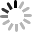

In [213]:
dev_data[2]